# GANisme — 08. Confirmation et modèle final (portraits 64×80)

L'étude Optuna (notebook 07) a désigné deux réglages nettement meilleurs que nos trois premiers modèles, mais avec
trois réserves : **un seul entraînement par essai**, **300 époques seulement** (les meilleurs essais progressaient
encore), et **aucun poids sauvegardé**. Ce notebook lève ces réserves.

**Protocole** (`src/confirm_best.py`) :

| | |
|---|---|
| Réglages | essais n°26 et n°27 de l'étude, relus dans la base Optuna |
| Durée | **600 époques** (au lieu de 300) |
| Répétitions | **3 graines** par réglage (42, 1, 2) → 6 entraînements |
| Évaluation | complète (FID, KID, précision/rappel, mémorisation…), toutes les 25 époques, protocole du notebook 03 |
| Checkpoints | meilleur FID et dernière époque |

| Réglage | Perte | Norm. spectrale | lr G | lr D | Adam β₁ / β₂ | Mises à jour de D | DiffAugment | Batch |
|---|---|---|---|---|---|---|---|---|
| **n°26** | BCE | oui | 3,0·10⁻⁴ | 5,0·10⁻⁴ | 0 / 0,999 | 2 | couleur + translation | 64 |
| **n°27** | BCE | non | 9,3·10⁻⁵ | 9,1·10⁻⁴ | 0 / 0,999 | 2 | couleur + translation | 64 |

**Questions posées** : le gain d'Optuna est-il reproductible ? Entraîner plus longtemps aide-t-il ? Lequel des deux
réglages retenir ? Quel est le modèle final ?

In [1]:
import json
import shutil
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
from matplotlib_inline.backend_inline import set_matplotlib_formats

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds          # noqa: E402
import generate as gn         # noqa: E402
import metrics as mt          # noqa: E402

FIG_DIR = ROOT / "reports" / "figures"
RUNS = ROOT / "runs"
SIZE = (64, 80)
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"confirm_{name}.png")


CONFIGS = {26: ("réglage n°26 (avec norm. spectrale)", CAT[0]), 27: ("réglage n°27 (sans)", CAT[1])}
runs = {}
for d in sorted(RUNS.glob("optuna*_portrait_64_s*")):
    n, seed = int(d.name.split("_")[0].replace("optuna", "")), int(d.name.rsplit("_s", 1)[1])
    runs[(n, seed)] = {"name": d.name, "eval": pd.read_csv(d / "eval.csv"), "hist": pd.read_csv(d / "history.csv")}
print(f"{len(runs)} entraînements :", [v["name"] for v in runs.values()])

baselines = pd.read_csv(ROOT / "reports" / "metrics" / "baselines.csv")
bl = baselines[(baselines["genre"] == "portrait") & (baselines["résolution"] == "64×80")].set_index("baseline")

6 entraînements : ['optuna26_portrait_64_s1', 'optuna26_portrait_64_s2', 'optuna26_portrait_64_s42', 'optuna27_portrait_64_s1', 'optuna27_portrait_64_s2', 'optuna27_portrait_64_s42']


## 1. Résultats des six entraînements

In [2]:
rows = []
for (n, seed), r in runs.items():
    e = r["eval"]
    best, last = e.loc[e["FID"].idxmin()], e.iloc[-1]
    at300 = e[e["epoch"] == 300].iloc[0]
    rows.append({"réglage": n, "graine": seed, "FID ép. 300": at300["FID"], "FID ép. 600": last["FID"],
                 "meilleur FID": best["FID"], "à l'époque": int(best["epoch"]), "FID_ntest": best["FID_ntest"],
                 "KID×1000": best["KID_x1000"], "précision": best["precision"], "rappel": best["recall"],
                 "couverture": best["coverage"], "mem_ratio": best["mem_ratio"], "copies": best["copies"],
                 "minutes": round(r["hist"]["seconds"].sum() / 60)})
R = pd.DataFrame(rows).sort_values(["réglage", "graine"]).reset_index(drop=True)
R.round({"FID ép. 300": 1, "FID ép. 600": 1, "meilleur FID": 1, "FID_ntest": 1, "KID×1000": 1, "précision": 2,
         "rappel": 2, "couverture": 2, "mem_ratio": 2, "copies": 3})

,réglage,graine,FID ép. 300,FID ép. 600,meilleur FID,à l'époque,FID_ntest,KID×1000,précision,rappel,couverture,mem_ratio,copies,minutes
0,26,1,81.0,54.5,54.5,600,97.5,37.3,0.62,0.28,0.54,1.11,0.000,29
1,26,2,77.4,59.0,55.9,550,99.3,39.4,0.63,0.25,0.49,1.11,0.000,29
2,26,42,71.2,56.0,55.7,550,100.4,37.1,0.61,0.26,0.48,1.12,0.000,30
3,27,1,70.6,60.8,60.0,575,101.1,41.5,0.67,0.22,0.51,1.09,0.001,26
4,27,2,92.2,71.8,69.9,550,110.0,49.6,0.62,0.18,0.39,1.10,0.000,26
5,27,42,86.0,60.2,60.2,600,103.3,40.6,0.63,0.22,0.50,1.11,0.000,26


In [3]:
agg = R.groupby("réglage")[["FID ép. 300", "FID ép. 600", "meilleur FID", "FID_ntest", "précision", "rappel", "couverture"]].agg(["mean", "std"]).round(2)
display(agg)

# Comparaison appariée : même graine, deux réglages
pair = R.pivot(index="graine", columns="réglage", values="FID ép. 600")
pair["écart (27 − 26)"] = pair[27] - pair[26]
print("FID à l'époque 600, par graine :")
display(pair.round(1))
spread26 = R.loc[R["réglage"] == 26, "FID ép. 600"]; spread27 = R.loc[R["réglage"] == 27, "FID ép. 600"]
print(f"Étendue entre graines — n°26 : {spread26.max() - spread26.min():.1f} points ; n°27 : {spread27.max() - spread27.min():.1f} points")
print(f"Écart moyen entre réglages : {pair['écart (27 − 26)'].mean():.1f} points (n°26 meilleur sur {(pair['écart (27 − 26)'] > 0).sum()} graine(s) sur {len(pair)})")

FID ép. 300        FID ép. 600       meilleur FID       FID_ntest  \
               mean    std        mean   std         mean   std      mean   
réglage                                                                     
26            76.57   4.96       56.50  2.29        55.35  0.75     99.09   
27            82.92  11.14       64.23  6.53        63.36  5.69    104.83   

              précision       rappel       couverture        
          std      mean   std   mean   std       mean   std  
réglage                                                      
26       1.45      0.62  0.01   0.27  0.01       0.50  0.03  
27       4.64      0.64  0.03   0.20  0.03       0.47  0.06

FID à l'époque 600, par graine :


réglage,26,27,écart (27 − 26)
graine,,,
1,54.5,60.8,6.3
2,59.0,71.8,12.8
42,56.0,60.2,4.2


Étendue entre graines — n°26 : 4.5 points ; n°27 : 11.6 points
Écart moyen entre réglages : 7.7 points (n°26 meilleur sur 3 graine(s) sur 3)


**Observations**

- **Le gain d'Optuna est confirmé et amplifié.** Les six entraînements finissent entre 54,5 et 71,8 de FID, contre 116
  pour le meilleur modèle d'avant l'étude.
- **Le réglage n°26 est meilleur sur les trois graines** (écart de 4 à 13 points, 7,7 en moyenne) : FID moyen à
  l'époque 600 de **56,5 ± 2,3**, contre 64,2 ± 6,5 pour le n°27.
- **Il est aussi beaucoup plus régulier** : 4,5 points d'étendue entre graines, contre 11,6 pour le n°27, dont une
  graine (la 2) décroche à 71,8.
- **Les scores d'Optuna étaient optimistes.** À l'époque 300, le réglage n°26 obtient ici 71 à 81 (68 dans l'étude)
  et le n°27 obtient 71 à 92 (73,5 dans l'étude). Optuna retient par construction les essais qui ont eu de la chance :
  c'est la « malédiction du vainqueur », et la raison pour laquelle une étape de confirmation est indispensable.
- **Précision ≈ 0,62, rappel ≈ 0,27** pour le n°26 : le rappel est 2,5 fois celui du modèle n°2 (0,11). Le n°27 a une
  précision équivalente mais un rappel plus faible (0,20) : c'est sur la diversité que les deux réglages se séparent.
- **Aucune mémorisation** : `mem_ratio` ≈ 1,11 et 0 % de copies sur les six entraînements.

## 2. Courbes d'apprentissage

Trois questions : les graines donnent-elles des trajectoires proches ? Les 300 époques supplémentaires servent-elles ?
Y a-t-il des effondrements ?

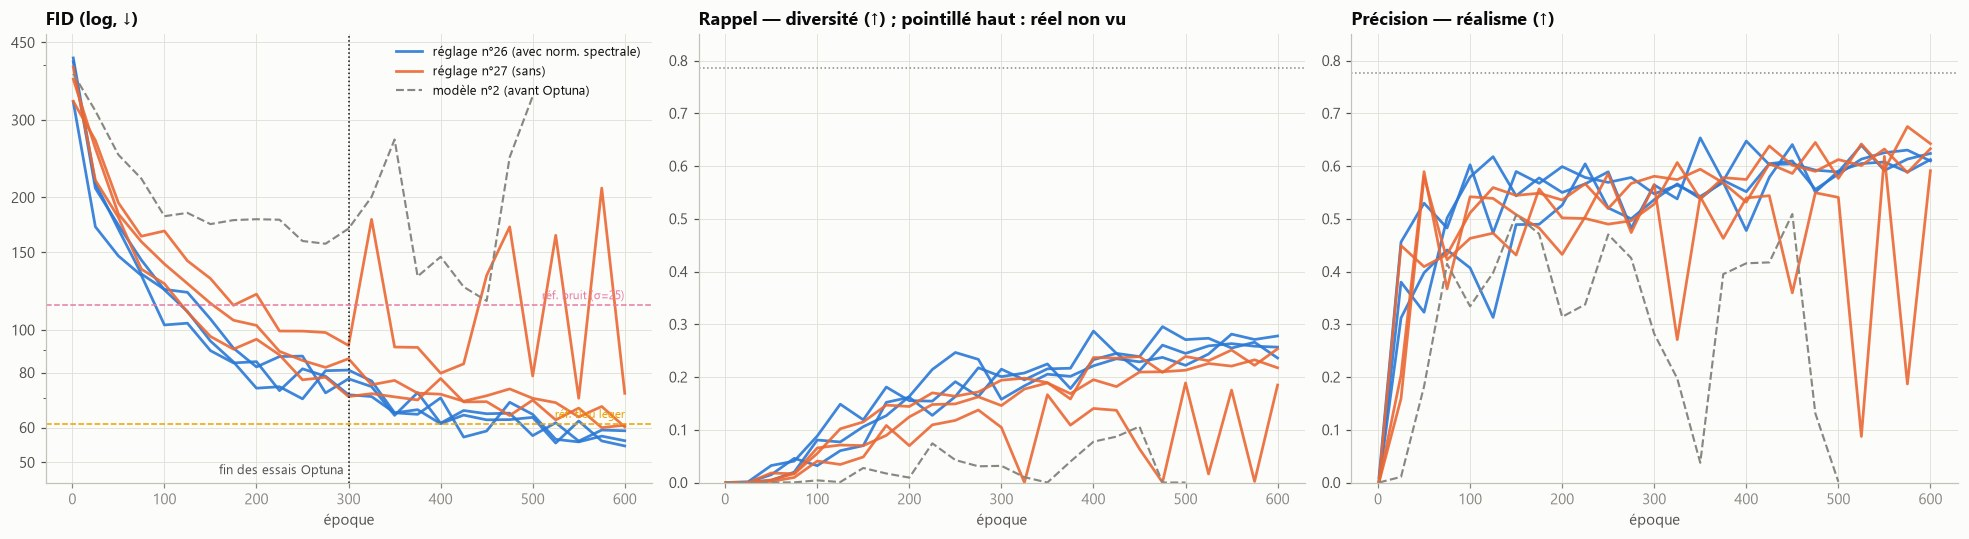

Gain de FID entre l'époque 300 et l'époque 600 :


,mean,min,max
réglage,,,
26,20.1,15.2,26.5
27,18.7,9.8,25.8


FID gagné sur les 100 dernières époques : {'26/s1': np.float64(8.8), '26/s2': np.float64(-1.5), '26/s42': np.float64(8.3), '27/s1': np.float64(8.5), '27/s2': np.float64(6.8), '27/s42': np.float64(9.7)}


In [4]:
ref2 = pd.read_csv(RUNS / "dcgan_diffaug_portrait_64" / "eval.csv")       # meilleur modèle d'avant Optuna
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (n, seed), r in runs.items():
    e, (lbl, col) = r["eval"], CONFIGS[n]
    first = seed == min(s for (m, s) in runs if m == n)
    axes[0].plot(e["epoch"], e["FID"], color=col, lw=1.8, alpha=0.9, label=lbl if first else None)
    axes[1].plot(e["epoch"], e["recall"], color=col, lw=1.8, alpha=0.9)
    axes[2].plot(e["epoch"], e["precision"], color=col, lw=1.8, alpha=0.9)
axes[0].plot(ref2["epoch"], ref2["FID"], color=MUTED, lw=1.4, ls="--", label="modèle n°2 (avant Optuna)")
axes[0].axvline(300, color=INK, lw=1, ls=":"); axes[0].text(295, 47, "fin des essais Optuna", ha="right", fontsize=8.5, color=INK2)
for lbl, c in [("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4])]:
    axes[0].axhline(bl.loc[lbl, "FID"], color=c, ls="--", lw=1)
    axes[0].text(600, bl.loc[lbl, "FID"] * 1.03, f"réf. {lbl.lower()}", ha="right", fontsize=8, color=c)
axes[0].set_yscale("log"); axes[0].set_yticks([50, 60, 80, 100, 150, 200, 300, 450])
axes[0].yaxis.set_major_formatter(mtick.ScalarFormatter()); axes[0].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[0].set_ylim(45, 470); axes[0].set_title("FID (log, ↓)"); axes[0].legend(loc="upper right", fontsize=8.5)
axes[1].plot(ref2["epoch"], ref2["recall"], color=MUTED, lw=1.4, ls="--")
axes[1].axhline(bl.loc["Réel non vu (test)", "recall"], color=MUTED, ls=":", lw=1)
axes[1].set_ylim(0, 0.85); axes[1].set_title("Rappel — diversité (↑) ; pointillé haut : réel non vu")
axes[2].plot(ref2["epoch"], ref2["precision"], color=MUTED, lw=1.4, ls="--")
axes[2].axhline(bl.loc["Réel non vu (test)", "precision"], color=MUTED, ls=":", lw=1)
axes[2].set_ylim(0, 0.85); axes[2].set_title("Précision — réalisme (↑)")
for ax in axes:
    ax.set_xlabel("époque")
plt.tight_layout()
save(fig, "01_curves")
plt.show()

gain = R.assign(gain=R["FID ép. 300"] - R["FID ép. 600"]).groupby("réglage")["gain"].agg(["mean", "min", "max"]).round(1)
print("Gain de FID entre l'époque 300 et l'époque 600 :")
display(gain)
slope = {k: (r["eval"].set_index("epoch")["FID"].loc[500] - r["eval"].set_index("epoch")["FID"].loc[600]) for k, r in runs.items()}
print("FID gagné sur les 100 dernières époques :", {f"{n}/s{s}": round(v, 1) for (n, s), v in slope.items()})

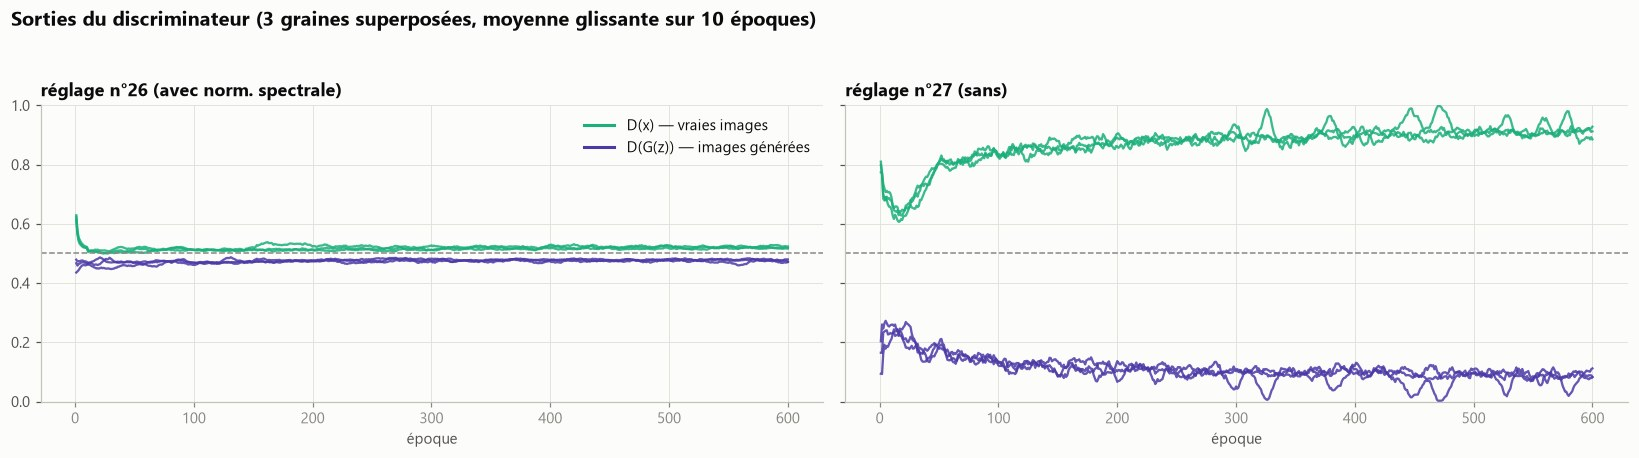

In [5]:
# Rapport de force entre les deux réseaux : probabilité « réel » donnée par D aux vraies et aux fausses images
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, n in zip(axes, CONFIGS):
    for (m, seed), r in runs.items():
        if m != n:
            continue
        h = r["hist"]
        ax.plot(h["epoch"], h["d_real"].rolling(10, min_periods=1).mean(), color=CAT[2], lw=1.5, alpha=0.85)
        ax.plot(h["epoch"], h["d_fake"].rolling(10, min_periods=1).mean(), color=CAT[6], lw=1.5, alpha=0.85)
    ax.axhline(0.5, color=MUTED, ls="--", lw=1); ax.set_ylim(0, 1); ax.set_xlabel("époque")
    ax.set_title(CONFIGS[n][0])
axes[0].plot([], [], color=CAT[2], label="D(x) — vraies images"); axes[0].plot([], [], color=CAT[6], label="D(G(z)) — images générées")
axes[0].legend(loc="upper right")
fig.suptitle("Sorties du discriminateur (3 graines superposées, moyenne glissante sur 10 époques)", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94))
save(fig, "02_discriminator")
plt.show()

**Observations**

- **Les 300 époques supplémentaires rapportent environ 20 points de FID** aux deux réglages (de ~77 à ~56 pour le
  n°26). Votre remarque sur la convergence était donc juste : à 300 époques, les essais d'Optuna étaient loin
  d'avoir fini d'apprendre.
- **L'apprentissage n'est toujours pas terminé à l'époque 600** : cinq entraînements sur six gagnent encore 7 à 10
  points sur les 100 dernières époques. Un entraînement plus long améliorerait probablement encore le score.
- **Le réglage n°26 est remarquablement stable** : trois courbes presque superposées, sans aucun pic. Son
  discriminateur reste collé à l'équilibre théorique — il donne 0,52 aux vraies images et 0,47 aux fausses, du début à
  la fin. C'est la première fois dans le projet qu'on observe un jeu réellement équilibré.
- **Le réglage n°27 ne l'est pas** : son discriminateur domine (0,9 contre 0,1, comme dans le modèle n°1), et une de
  ses graines subit des **crises violentes** (FID qui remonte à 150-200 puis redescend, précision qui tombe à 0,1).
- **La normalisation spectrale compte donc plus que ne le disait l'étude Optuna** (importance estimée à 3 %). Sur un
  entraînement court et une seule graine, les deux réglages semblaient équivalents ; sur 600 époques et trois graines,
  celui qui en est dépourvu est moins bon et moins fiable. Elle n'améliore pas tant le meilleur score que la
  **régularité**.

## 3. Choix du modèle final

Règle fixée avant de regarder les images : on retient le **réglage** dont le FID moyen à l'époque 600 est le plus bas,
puis, parmi ses trois graines, le **checkpoint au meilleur FID**. Ses poids sont copiés dans
`models/portrait_64.pt`, chemin stable que lira l'application Streamlit.

In [6]:
best_cfg = R.groupby("réglage")["FID ép. 600"].mean().idxmin()
final = R[R["réglage"] == best_cfg].sort_values("meilleur FID").iloc[0]
FINAL_RUN = runs[(int(final["réglage"]), int(final["graine"]))]["name"]
(ROOT / "models").mkdir(exist_ok=True)
shutil.copy2(RUNS / FINAL_RUN / "checkpoints" / "best.pt", ROOT / "models" / "portrait_64.pt")
G, info = gn.load_generator(FINAL_RUN, "best")
print(f"Modèle final : {FINAL_RUN} — époque {info['epoch']}, FID {info['scores']['FID']:.1f}")
print("Copié vers models/portrait_64.pt")
pd.Series({k: v for k, v in info["scores"].items() if k not in ("iters", "train_minutes", "n")}).round(3).to_frame("modèle final").T

Modèle final : optuna26_portrait_64_s1 — époque 600, FID 54.5
Copié vers models/portrait_64.pt


,epoch,FID,FID_ntest,KID_x1000,KID_std_x1000,IS,IS_std,precision,recall,density,coverage,mem_ratio,copies
modèle final,600.0,54.496,97.549,37.325,1.225,3.424,0.116,0.624,0.278,0.61,0.536,1.108,0.0


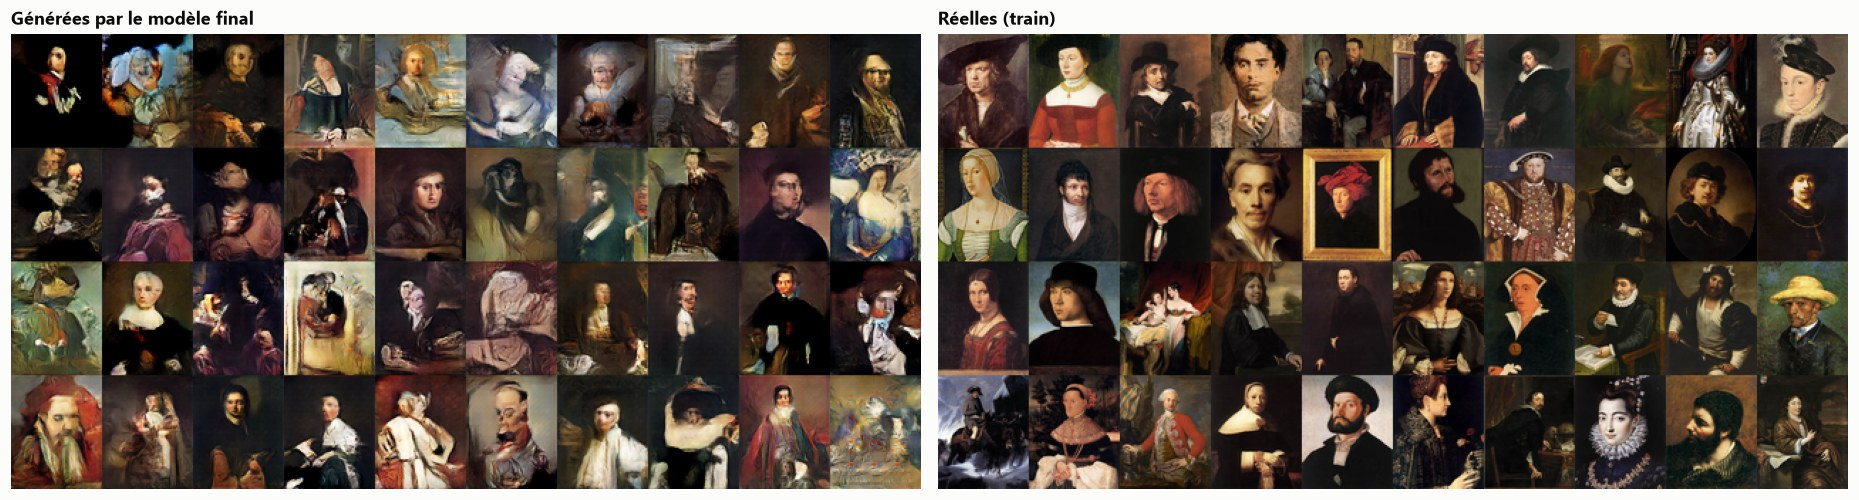

In [7]:
fake = gn.sample(G, 40, seed=123)
real = ds.load_split("portrait", "train", SIZE)
real = real[np.random.default_rng(123).choice(len(real), 40, replace=False)]
mosaic = lambda imgs, ncol=10: np.concatenate([np.concatenate(list(imgs[i:i + ncol]), axis=1) for i in range(0, len(imgs), ncol)])
fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))
for ax, imgs, title in [(axes[0], fake, "Générées par le modèle final"), (axes[1], real, "Réelles (train)")]:
    ax.imshow(mosaic(imgs)); ax.axis("off"); ax.set_title(title)
plt.tight_layout()
save(fig, "03_final_vs_real")
plt.show()

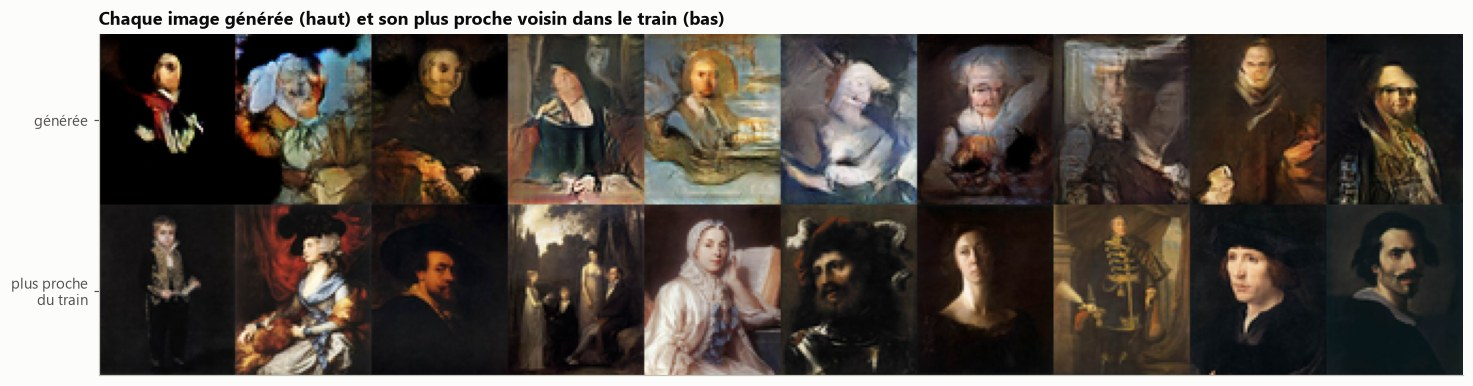

In [8]:
# Contrôle de la mémorisation : plus proche voisin dans le train (espace Inception)
ref = mt.Reference.load_or_compute("portrait", SIZE, ds.DATASETS / "portrait")
train_all = ds.load_split("portrait", "train", SIZE)
f_fake, _ = mt.extract_features(fake[:10])
nn_idx = torch.cdist(torch.from_numpy(f_fake).float(), torch.from_numpy(ref.train).float()).argmin(1).numpy()
fig, ax = plt.subplots(figsize=(16, 4.2))
ax.imshow(np.concatenate([np.concatenate(list(fake[:10]), axis=1), np.concatenate([train_all[i] for i in nn_idx], axis=1)]))
ax.set_xticks([]); ax.set_yticks([SIZE[1] / 2, SIZE[1] * 1.5], ["générée", "plus proche\ndu train"]); ax.grid(False)
ax.set_title("Chaque image générée (haut) et son plus proche voisin dans le train (bas)")
save(fig, "04_nearest_neighbors")
plt.show()

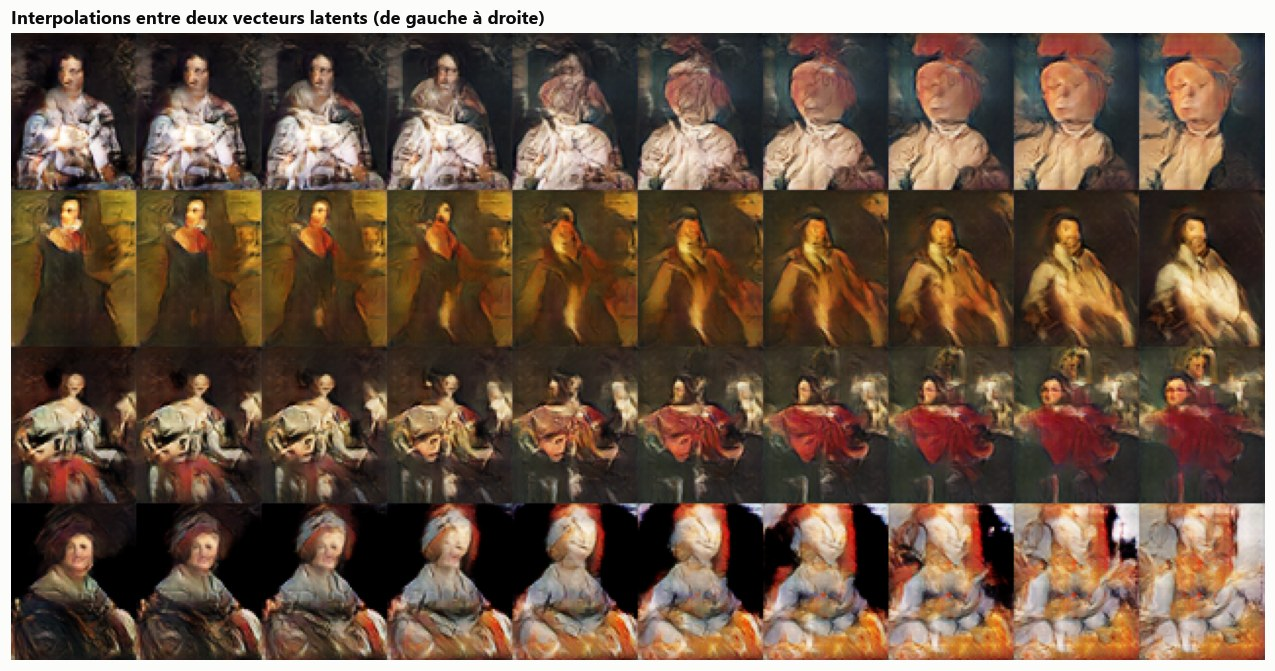

In [9]:
# Interpolations dans l'espace latent
def slerp(a, b, t):
    omega = torch.acos((a / a.norm() * b / b.norm()).sum().clamp(-1, 1))
    return (torch.sin((1 - t) * omega) * a + torch.sin(t * omega) * b) / torch.sin(omega)


dev = next(G.parameters()).device
g = torch.Generator().manual_seed(7)
strips = []
with torch.no_grad():
    for _ in range(4):
        a, b = torch.randn(G.nz, generator=g), torch.randn(G.nz, generator=g)
        z = torch.stack([slerp(a, b, t) for t in torch.linspace(0, 1, 10)]).to(dev)
        x = G(z).clamp(-1, 1).add(1).mul(127.5).round().to(torch.uint8).permute(0, 2, 3, 1).cpu().numpy()
        strips.append(np.concatenate(list(x), axis=1))
fig, ax = plt.subplots(figsize=(16, 7.4))
ax.imshow(np.concatenate(strips)); ax.axis("off")
ax.set_title("Interpolations entre deux vecteurs latents (de gauche à droite)")
save(fig, "05_interpolation")
plt.show()

**Observations**

- **Modèle final : réglage n°26, graine 1, époque 600 — FID 54,5.** Ses poids sont dans `models/portrait_64.pt`.
- **Les images sont nettement plus lisibles** que celles des premiers modèles : bustes bien construits, vêtements
  détaillés (cols blancs, drapés, chapeaux), fonds variés (sombres, bleus, dorés), et **des visages souvent
  reconnaissables** (yeux, nez, bouche, barbe). Beaucoup restent déformés, et certaines images sont ratées.
- **Pas de copie** : les plus proches voisins dans le train sont d'autres œuvres, qui partagent seulement l'ambiance.
- **Interpolations continues** : un personnage se transforme progressivement en un autre (le vêtement change de
  couleur, la tête tourne, le fond s'éclaircit), sans saut.

**Trois réserves à garder en tête :**
1. **Le FID de 54,5 n'est pas « meilleur que le réel » (57,6).** Les deux ne sont pas mesurés sur le même nombre
   d'images. À effectif égal, le modèle est à **97,5** contre **57,6** pour de vraies peintures jamais vues : l'écart
   reste important.
2. **La diversité reste le point faible** : rappel de 0,28 contre 0,79 pour le réel. Le générateur ne couvre encore
   qu'une partie de la variété des portraits.
3. **Léger biais de sélection** : le modèle final est le meilleur de trois graines et de 24 évaluations chacune. Le
   chiffre honnête à citer pour « ce que donne ce réglage » est la moyenne : **FID 56,5 ± 2,3** à l'époque 600.

## 4. Bilan : tous les modèles du projet (portraits 64×80)

In [10]:
reg = pd.read_csv(ROOT / "reports" / "metrics" / "models.csv")
reg = reg[(reg["genre"] == "portrait") & (reg["size"] == "64x80") & (reg["checkpoint"] == "best")]
labels = {"dcgan_portrait_64": "n°1 · DCGAN", "dcgan_diffaug_portrait_64": "n°2 · + DiffAugment",
          "sngan_diffaug_portrait_64": "n°3 · + norm. spectrale + hinge"}
cols = ["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
first3 = reg[reg["run"].isin(labels)].assign(modèle=lambda d: d["run"].map(labels)).set_index("modèle")[cols]
conf = reg[reg["run"].str.startswith("optuna")]
means = conf.assign(modèle=conf["run"].str.extract(r"optuna(\d+)")[0].map(lambda n: f"Optuna n°{n} · moyenne de {int((conf['run'].str.startswith('optuna' + n)).sum())} graines")) \
            .groupby("modèle")[cols].mean()
fin = reg[reg["run"] == FINAL_RUN].assign(modèle="MODÈLE FINAL").set_index("modèle")[cols]
refs = bl.loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Mode collapse (20 images)"], [c for c in cols if c != "epoch"]]
refs.index = "réf. · " + refs.index
summary = pd.concat([first3, means, fin, refs]).round(3)
summary.to_csv(ROOT / "reports" / "metrics" / "summary_portrait_64.csv")
summary

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
n°1 · DCGAN,400.000,129.988,169.740,119.640,0.372,0.072,0.166,0.109,1.199,0.000
n°2 · + DiffAugment,450.000,116.392,161.252,100.441,0.509,0.106,0.304,0.201,1.182,0.000
n°3 · + norm. spectrale + hinge,500.000,197.609,234.930,205.255,0.165,0.001,0.040,0.014,1.275,0.000
Optuna n°26 · moyenne de 3 graines,566.667,55.352,99.089,37.946,0.619,0.265,0.574,0.499,1.110,0.000
Optuna n°27 · moyenne de 3 graines,575.000,63.359,104.829,43.922,0.642,0.205,0.577,0.468,1.102,0.000
MODÈLE FINAL,600.000,54.496,97.549,37.325,0.624,0.278,0.610,0.536,1.108,0.000
réf. · Réel non vu (test),NaN,57.562,57.562,-0.223,0.776,0.785,0.913,0.396,1.000,0.010
réf. · Flou léger,NaN,61.232,106.555,56.554,0.684,0.712,0.268,0.671,1.025,0.029
réf. · Bruit (σ=25),NaN,113.950,157.661,121.322,0.141,0.237,0.037,0.111,1.177,0.001
réf. · Mode collapse (20 images),NaN,196.333,197.167,15.759,1.000,0.006,0.999,0.029,0.001,1.000


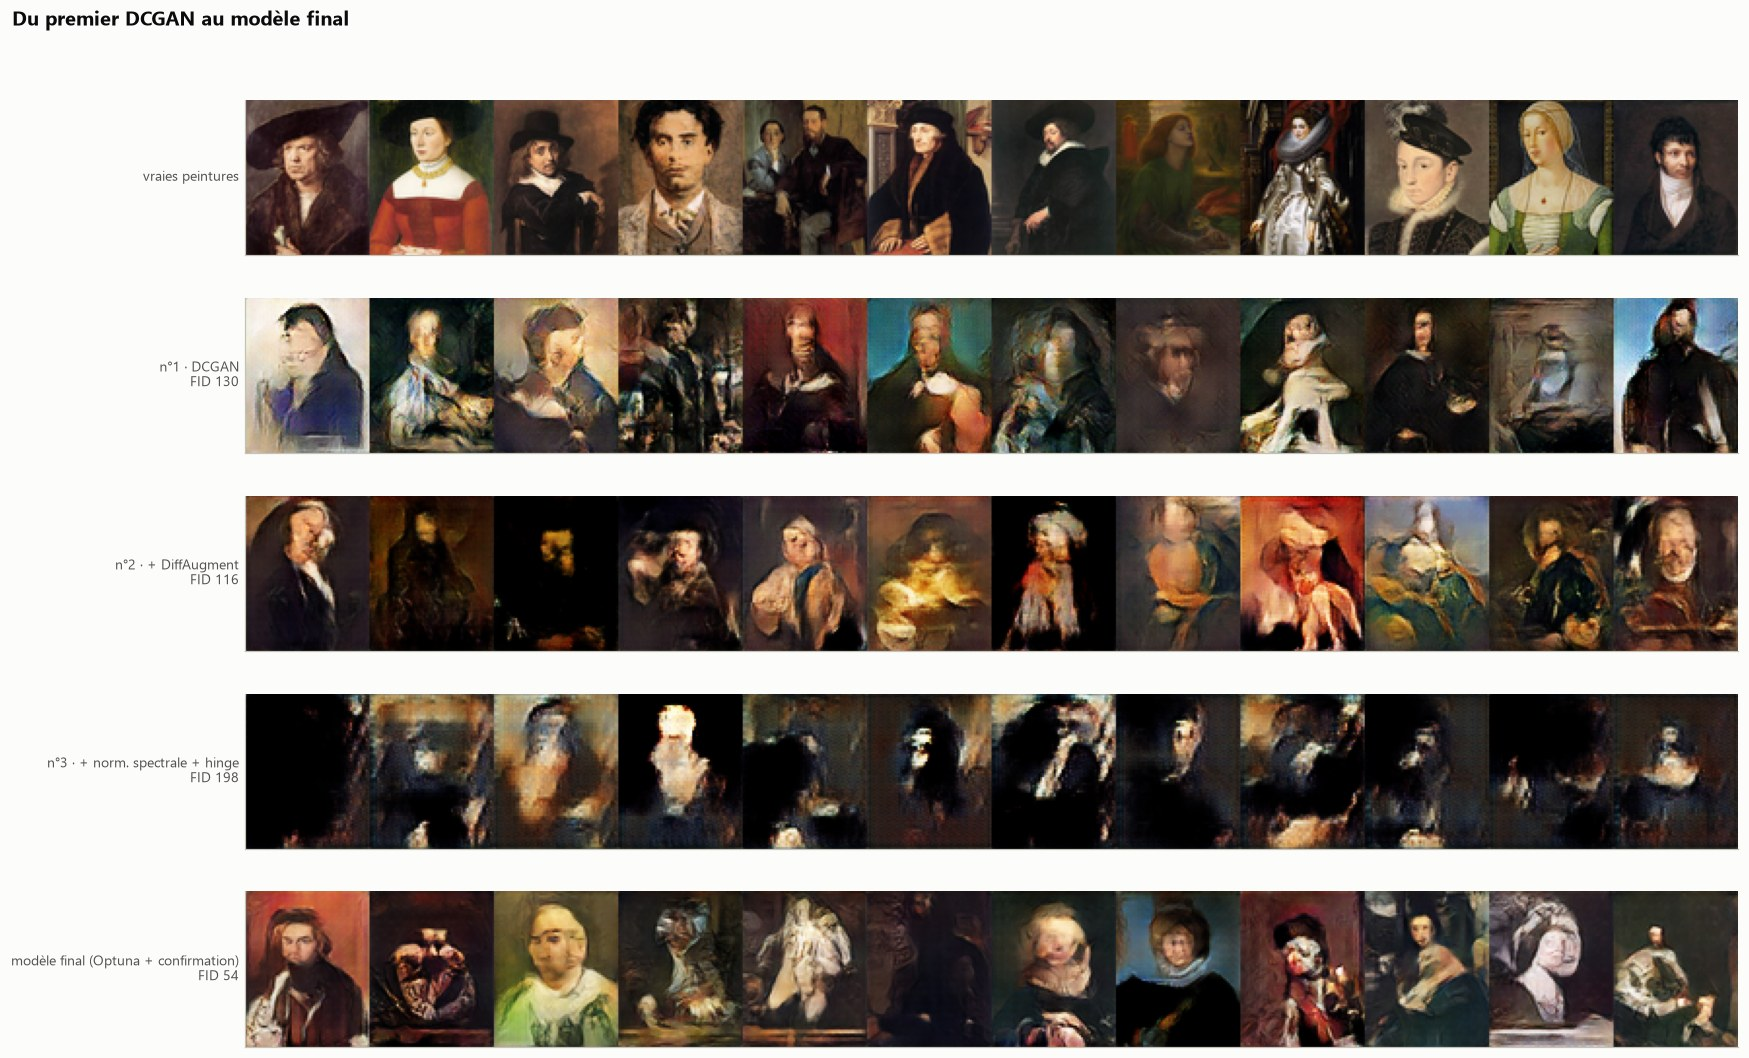

In [11]:
# Planche comparative : mêmes vecteurs latents pour tous les modèles
order = [("dcgan_portrait_64", "n°1 · DCGAN"), ("dcgan_diffaug_portrait_64", "n°2 · + DiffAugment"),
         ("sngan_diffaug_portrait_64", "n°3 · + norm. spectrale + hinge"), (FINAL_RUN, "modèle final (Optuna + confirmation)")]
fig, axes = plt.subplots(len(order) + 1, 1, figsize=(16, 1.9 * (len(order) + 1) + 0.4))
axes[0].imshow(np.concatenate(list(real[:12]), axis=1)); axes[0].set_ylabel("vraies peintures", rotation=0, ha="right", va="center", fontsize=9)
for ax, (run, lbl) in zip(axes[1:], order):
    g_, i_ = gn.load_generator(run, "best")
    ax.imshow(np.concatenate(list(gn.sample(g_, 12, seed=2024)), axis=1))
    ax.set_ylabel(f"{lbl}\nFID {i_['scores']['FID']:.0f}", rotation=0, ha="right", va="center", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Du premier DCGAN au modèle final", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
save(fig, "06_all_models")
plt.show()

## 5. Conclusion

| Question | Réponse |
|---|---|
| Le gain d'Optuna est-il reproductible ? | **Oui.** Six entraînements sur six font au moins 1,6 fois mieux que le modèle n°2 |
| Entraîner plus longtemps aide-t-il ? | **Oui**, ~20 points de FID entre les époques 300 et 600, et ce n'est pas fini |
| Quel réglage retenir ? | **Le n°26** : meilleur sur les trois graines, et bien plus régulier |
| Quel est le modèle final ? | n°26, graine 1, époque 600 : **FID 54,5**, précision 0,62, rappel 0,28 |

**Le chemin parcouru sur les portraits 64×80 :**

| Étape | FID | Rappel | Ce qu'on a appris |
|---|---|---|---|
| n°1 · DCGAN | 130 | 0,07 | le discriminateur apprend le train par cœur |
| n°2 · + DiffAugment | 116 | 0,11 | meilleur, mais instable |
| n°3 · + normalisation spectrale | 198 | 0,00 | stable, mais mauvais hyperparamètres |
| Optuna, 300 époques | ≈ 68 | 0,18 | l'équilibre se règle par l'entraînement de D |
| **Confirmation, 600 époques** | **56,5 ± 2,3** | **0,27** | gain confirmé, convergence lente |

Le FID a été **divisé par 2,3** depuis le premier modèle, **sans changer une ligne de l'architecture du générateur**.
Toute l'amélioration vient de l'équilibre entre les deux réseaux : augmentation des données vues par le
discriminateur, normalisation spectrale, deux mises à jour de D par itération, β₁ = 0, batch plus petit.

**Limites restantes :** visages encore souvent déformés (la résolution 64×80 leur laisse une quinzaine de pixels),
diversité loin du réel, apprentissage non terminé à 600 époques.

**Suites possibles :**
- **l'application Streamlit**, désormais possible avec `models/portrait_64.pt` ;
- le passage en **128×160**, qui est le levier le plus direct pour les visages ;
- le même réglage appliqué aux **paysages** (le jeu de données est prêt).